In [1]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow_datasets as tfds
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

2025-06-17 07:25:56.055682: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750145156.249878      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750145156.305910      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# Load Dataset 
(ds_train, ds_test), ds_info = tfds.load(
    'emnist/letters',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

def tfds_to_numpy(ds):
    images = []
    labels = []
    for img, label in tfds.as_numpy(ds):
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

X, y = tfds_to_numpy(ds_train)

# Normalize
X = X.astype('float32') / 255.0
X = X.reshape(-1, 28, 28, 1)

# Labels start from 1 to 26 → shifting to 0 to 25
y = y - 1

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

...

I0000 00:00:1750145180.781143      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1750145180.782023      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.N4JW3X_3.1.0/emnist-train.tfrecord*...:   0%|   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.N4JW3X_3.1.0/emnist-test.tfrecord*...:   0%|    …

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/letters/3.1.0. Subsequent calls will reuse this data.


In [3]:
# Model Definition
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(26, activation='softmax')  # 26 classes for A-Z
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# Training
history = model.fit(X_train, y_train, epochs=10, validation_split=0.1, batch_size=128)

Epoch 1/10


I0000 00:00:1750145297.147368     106 service.cc:148] XLA service 0x7e366c0050a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750145297.148122     106 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1750145297.148142     106 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1750145297.394861     106 cuda_dnn.cc:529] Loaded cuDNN version 90300


 42/500 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2203 - loss: 2.8145

I0000 00:00:1750145299.583767     106 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6246 - loss: 1.2845 - val_accuracy: 0.8850 - val_loss: 0.3673
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8865 - loss: 0.3536 - val_accuracy: 0.9023 - val_loss: 0.3044
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9106 - loss: 0.2737 - val_accuracy: 0.9124 - val_loss: 0.2672
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9252 - loss: 0.2305 - val_accuracy: 0.9169 - val_loss: 0.2554
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9330 - loss: 0.1963 - val_accuracy: 0.9233 - val_loss: 0.2359
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9409 - loss: 0.1713 - val_accuracy: 0.9269 - val_loss: 0.2238
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9456 - loss: 0.1561 - val_accuracy: 0.9269 - val_loss: 0.2302
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9497 - loss: 0.1414 - val_accuracy: 0.9245 - val_

In [5]:
# Evaluation
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

555/555 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9307 - loss: 0.2241
Test Accuracy: 0.9282


555/555 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


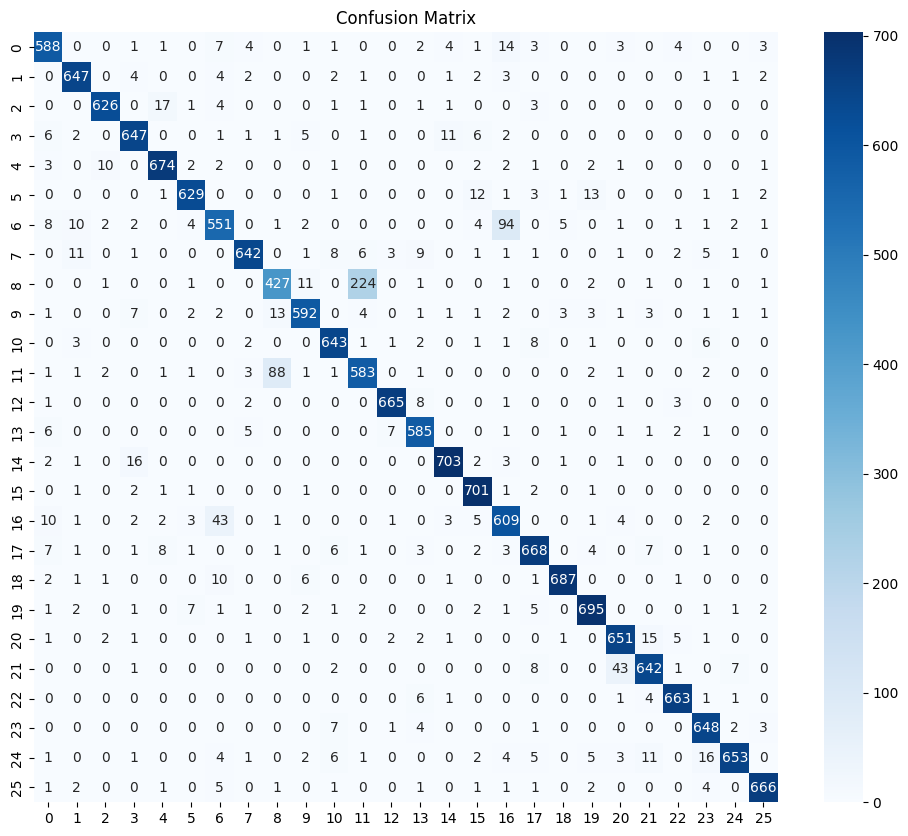

In [6]:
# Confusion Matrix
y_pred = np.argmax(model.predict(X_test), axis=-1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [7]:
# Save Model
model.save("handwritten_character_AZ_model.h5")